# Классификация сообщений мессенджера Авито
## Этап 6 — обучение модели (итеративный подход)

Обучаем классификатор на 5 классов: `normal`, `external`, `spam`, `harassment`, `threat`.
Идём **итеративно — от простого к лучшему**, на каждом шаге честно меряя метрики:

| Шаг | Модель | Идея |
|---|---|---|
| 0 | `DummyClassifier` | тривиальный ориентир (most-frequent) — показывает, почему accuracy бесполезен |
| 1 | TF-IDF (слова) + LogReg | простой «мешок слов» |
| 2 | TF-IDF (слова + символы) + LogReg | символьные n-граммы → устойчивость к опечаткам/обфускации |
| 3 | fine-tune `cointegrated/rubert-tiny2` | контекстный трансформер, ловит завуалированную токсичность |

### Требования из ТЗ, влияющие на решение

| Требование | Значение | Следствие |
|---|---|---|
| Латентность инференса | ≤ 80 мс (средн. 50, p98 ≤ 100) | лёгкая модель, CPU-инференс |
| Язык / стиль | русский, короткие сообщения, опечатки, сленг | subword / символьные признаки |
| Precision класса `normal` | ≥ 0.95 | не пропускать спам/угрозы как «обычное» |
| Recall по токсичным | максимальный | ловить как можно больше нарушений |
| Дисбаланс | `normal` 92% → `threat` 0.07% | взвешивание классов, аккуратные метрики |

**Критичность ошибок:** `normal` → токсичный (FN normal) — критично (валидное сообщение
не доставлено, срыв сделки); токсичный → `normal` — пропуск нарушения; ошибка между
токсичными классами — менее критична.


## 1. Обоснование выбора финальной модели

Главное ограничение — **латентность ≤ 80 мс на CPU**. Оно отсекает тяжёлые трансформеры.

| Модель | Параметры | CPU-латентность (короткий текст) | Русский | Вердикт |
|---|---|---|---|---|
| TF-IDF + LogReg | — | < 2 мс | через символьные n-граммы | бейзлайн |
| `cointegrated/rubert-tiny2` | 29M | ~10–30 мс | да (родной) | **финальная** |
| DeepPavlov/rubert-base | 180M | ~80–200 мс | да | не проходит p98 |
| mDeBERTa-v3-base | 280M | ~200–500 мс | да | только офлайн (этап 5) |

`rubert-tiny2` — единственный трансформер, влезающий в ≤ 80 мс на CPU, при этом
качественно лучше TF-IDF на скрытой токсичности. ruBERT-base / mDeBERTa дают +1–2%,
но не проходят по латентности (mDeBERTa использовалась только офлайн для разметки на этапе 5).


## 2. Окружение

Запуск на Apple Silicon (MPS) или Kaggle (CUDA). MPS включается автоматически.

In [1]:
# Kaggle: раскомментировать
# !pip install -q transformers datasets scikit-learn accelerate

import os, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support, ConfusionMatrixDisplay)
import torch

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE); torch.manual_seed(RANDOM_STATE)

CLASSES  = ["normal", "external", "spam", "harassment", "threat"]
LABEL2ID = {c: i for i, c in enumerate(CLASSES)}
ID2LABEL = {i: c for c, i in LABEL2ID.items()}

# Выбор устройства: CUDA (Kaggle) -> MPS (Apple) -> CPU
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print("Устройство для трансформера:", DEVICE)


Устройство для трансформера: mps


In [2]:
# Данные: Kaggle-датасет либо локальная папка
KAGGLE_DIR = "/kaggle/input/avito-augmented"
LOCAL_DIR  = "data/augmented"
DATA_DIR = KAGGLE_DIR if os.path.exists(KAGGLE_DIR) else LOCAL_DIR
print("DATA_DIR =", DATA_DIR)

train = pd.read_csv(f"{DATA_DIR}/train.csv")
val   = pd.read_csv(f"{DATA_DIR}/val.csv")
test  = pd.read_csv(f"{DATA_DIR}/test.csv")
for df in (train, val, test):
    df["text"] = df["text"].fillna("").astype(str)
    df["y"] = df["label"].map(LABEL2ID)

print(f"train={len(train):,}  val={len(val):,}  test={len(test):,}")
print("train:", train['label'].value_counts().to_dict())
print("test :", test['label'].value_counts().to_dict())


DATA_DIR = data/augmented


train=316,215  val=36,149  test=36,149
train: {'normal': 285493, 'harassment': 21249, 'external': 7139, 'spam': 2057, 'threat': 277}
test : {'normal': 35686, 'external': 432, 'spam': 22, 'harassment': 8, 'threat': 1}


## 3. Данные и метрика сравнения

- **train** — аугментированный (реальные Авито + AlexSham + ru_paradetox + синтетика).
- **val / test** — **только реальные сообщения Авито** → честная оценка.

> В val/test редкие классы единичны (`threat`≈1, `harassment`≈8 на 36k) — их recall
> статистически шумный. Опорные метрики: **macro-F1**, **normal-precision** (≥0.95) и
> **normal-recall** (FN normal критичны). Accuracy бесполезен из-за дисбаланса (92% `normal`).

Все модели сравниваем на **val**, финальную — отдельно на **test**.


In [3]:
# Единый помощник оценки: считает метрики, печатает отчёт, копит в RESULTS
RESULTS = {}

def evaluate(name, y_true, y_pred, latency_ms=None, verbose=True):
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=range(len(CLASSES)), average=None, zero_division=0)
    ni = LABEL2ID["normal"]
    macro_f1 = float(f1.mean())
    res = {"macro_f1": macro_f1,
           "normal_precision": float(p[ni]),
           "normal_recall": float(r[ni]),
           "latency_ms_p98": latency_ms}
    RESULTS[name] = res
    if verbose:
        print(f"===== {name} =====")
        print(classification_report(y_true, y_pred, labels=range(len(CLASSES)),
                                    target_names=CLASSES, digits=3, zero_division=0))
        print(f"macro-F1={macro_f1:.3f} | normal P={p[ni]:.3f} (цель >=0.95) | normal R={r[ni]:.3f}")
        if latency_ms is not None:
            print(f"латентность p98 (CPU, 1 сообщение) = {latency_ms:.2f} мс")
    return res

def latency_sklearn(pipe, sample, n=200):
    for _ in range(20): pipe.predict([sample])
    ts = []
    for _ in range(n):
        t = time.perf_counter(); pipe.predict([sample]); ts.append((time.perf_counter()-t)*1000)
    return float(np.percentile(ts, 98))

SAMPLE = "привет, скинь номер в тг договоримся по цене"


## 4. Шаг 0 — тривиальный ориентир (`DummyClassifier`)

Всегда предсказывает самый частый класс (`normal`). Показывает «дно»: accuracy ~0.99, но toxic-классы не ловятся вообще.

In [4]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="most_frequent").fit(train["text"], train["y"])
evaluate("0. Dummy (most-frequent)", val["y"], dummy.predict(val["text"]))
acc = (dummy.predict(val["text"]) == val["y"]).mean()
print(f"\nAccuracy={acc:.4f} — высокий, но macro-F1 близок к 0: метрика accuracy обманчива.")


===== 0. Dummy (most-frequent) =====
              precision    recall  f1-score   support

      normal      0.987     1.000     0.994     35686
    external      0.000     0.000     0.000       432
        spam      0.000     0.000     0.000        22
  harassment      0.000     0.000     0.000         8
      threat      0.000     0.000     0.000         1

    accuracy                          0.987     36149
   macro avg      0.197     0.200     0.199     36149
weighted avg      0.975     0.987     0.981     36149

macro-F1=0.199 | normal P=0.987 (цель >=0.95) | normal R=1.000

Accuracy=0.9872 — высокий, но macro-F1 близок к 0: метрика accuracy обманчива.


## 5. Шаг 1 — простой «мешок слов» (TF-IDF слова + LogReg)

Словные n-граммы (1–2) + логистическая регрессия с балансировкой классов.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline, FeatureUnion

m1 = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="word", ngram_range=(1, 2),
                              min_df=3, max_features=100_000, sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=1000, C=4.0, class_weight="balanced")),
])
t0 = time.time(); m1.fit(train["text"], train["y"]); print(f"обучение: {time.time()-t0:.1f} c")
evaluate("1. TF-IDF слова + LogReg", val["y"], m1.predict(val["text"]),
         latency_ms=latency_sklearn(m1, SAMPLE))


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


обучение: 16.0 c


===== 1. TF-IDF слова + LogReg =====
              precision    recall  f1-score   support

      normal      0.997     0.951     0.973     35686
    external      0.227     0.727     0.345       432
        spam      0.057     0.500     0.102        22
  harassment      0.014     0.875     0.027         8
      threat      0.000     0.000     0.000         1

    accuracy                          0.948     36149
   macro avg      0.259     0.611     0.289     36149
weighted avg      0.987     0.948     0.965     36149

macro-F1=0.289 | normal P=0.997 (цель >=0.95) | normal R=0.951
латентность p98 (CPU, 1 сообщение) = 0.86 мс


{'macro_f1': 0.2894989631468313,
 'normal_precision': 0.9966520807024757,
 'normal_recall': 0.9509891834332792,
 'latency_ms_p98': 0.8621989985840636}

## 6. Шаг 2 — улучшенный TF-IDF (слова + символы) + LogReg

Добавляем **символьные n-граммы (3–5)**: они ловят опечатки и обфускацию
(`т*г`, `телега`, `т е л е г а`), которые словный токенизатор пропускает.


In [6]:
m2 = Pipeline([
    ("features", FeatureUnion([
        ("word", TfidfVectorizer(analyzer="word", ngram_range=(1, 2),
                                 min_df=3, max_features=100_000, sublinear_tf=True)),
        ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5),
                                 min_df=3, max_features=200_000, sublinear_tf=True)),
    ])),
    ("clf", LogisticRegression(max_iter=1000, C=4.0, class_weight="balanced")),
])
t0 = time.time(); m2.fit(train["text"], train["y"]); print(f"обучение: {time.time()-t0:.1f} c")
evaluate("2. TF-IDF слова+символы + LogReg", val["y"], m2.predict(val["text"]),
         latency_ms=latency_sklearn(m2, SAMPLE))


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


обучение: 55.5 c


===== 2. TF-IDF слова+символы + LogReg =====
              precision    recall  f1-score   support

      normal      0.999     0.988     0.993     35686
    external      0.566     0.880     0.689       432
        spam      0.214     0.545     0.308        22
  harassment      0.062     1.000     0.117         8
      threat      0.000     0.000     0.000         1

    accuracy                          0.986     36149
   macro avg      0.368     0.683     0.421     36149
weighted avg      0.993     0.986     0.989     36149

macro-F1=0.421 | normal P=0.999 (цель >=0.95) | normal R=0.988
латентность p98 (CPU, 1 сообщение) = 1.44 мс


{'macro_f1': 0.42131856267014794,
 'normal_precision': 0.998639879856054,
 'normal_recall': 0.9875861682452503,
 'latency_ms_p98': 1.4398658398567934}

## 7. Шаг 3 — fine-tune `cointegrated/rubert-tiny2`

Компактный русский BERT (29M). Дисбаланс компенсируем **взвешенным
кросс-энтропийным loss** (веса обратно пропорциональны частоте класса).
На Apple Silicon обучение идёт на MPS, на Kaggle — на CUDA.


In [7]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding)
from datasets import Dataset

MODEL_NAME = "cointegrated/rubert-tiny2"
MAX_LEN = 128
EPOCHS = 3

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
def to_ds(df):
    ds = Dataset.from_pandas(df[["text", "y"]].rename(columns={"y": "labels"}),
                             preserve_index=False)
    return ds.map(lambda b: tokenizer(b["text"], truncation=True, max_length=MAX_LEN),
                  batched=True, remove_columns=["text"])
ds_train, ds_val, ds_test = to_ds(train), to_ds(val), to_ds(test)

# Веса классов (обратная частота)
counts = train["y"].value_counts().sort_index().values.astype(float)
class_weights = torch.tensor(counts.sum() / (len(counts) * counts), dtype=torch.float)
print("веса классов:", {CLASSES[i]: round(float(w),2) for i,w in enumerate(class_weights)})


Map:   0%|          | 0/316215 [00:00<?, ? examples/s]

Map:   0%|          | 0/36149 [00:00<?, ? examples/s]

Map:   0%|          | 0/36149 [00:00<?, ? examples/s]

веса классов: {'normal': 0.22, 'external': 8.86, 'spam': 30.75, 'harassment': 2.98, 'threat': 228.31}


In [8]:
class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, **kw):
        super().__init__(**kw)
        self.class_weights = class_weights
    def compute_loss(self, model, inputs, return_outputs=False, **kw):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(outputs.logits.device))
        loss = loss_fct(outputs.logits.view(-1, len(CLASSES)), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def hf_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    p, r, f1, _ = precision_recall_fscore_support(
        labels, preds, labels=range(len(CLASSES)), average=None, zero_division=0)
    return {"macro_f1": float(f1.mean()),
            "normal_precision": float(p[LABEL2ID['normal']]),
            "normal_recall": float(r[LABEL2ID['normal']])}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(CLASSES), id2label=ID2LABEL, label2id=LABEL2ID)


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [9]:
import inspect
args = TrainingArguments(
    output_dir="rubert_tiny2_avito",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=256,
    learning_rate=3e-5, weight_decay=0.01, warmup_ratio=0.1,
    eval_strategy="epoch", save_strategy="no",
    fp16=(DEVICE == "cuda"),          # fp16 только на CUDA; на MPS/CPU выключен
    logging_steps=200, disable_tqdm=True, report_to="none",
)
collator = DataCollatorWithPadding(tokenizer)
tkw = dict(class_weights=class_weights, model=model, args=args,
           train_dataset=ds_train, eval_dataset=ds_val,
           data_collator=collator, compute_metrics=hf_metrics)
# совместимость: transformers>=5 — processing_class, <5 — tokenizer
if "processing_class" in inspect.signature(Trainer.__init__).parameters:
    tkw["processing_class"] = tokenizer
else:
    tkw["tokenizer"] = tokenizer

trainer = WeightedTrainer(**tkw)
t0 = time.time(); trainer.train(); print(f"\nобучение rubert-tiny2: {(time.time()-t0)/60:.1f} мин")


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'loss': '1.578', 'grad_norm': '2.167', 'learning_rate': '4.026e-06', 'epoch': '0.04048'}


{'loss': '1.449', 'grad_norm': '2.63', 'learning_rate': '8.071e-06', 'epoch': '0.08096'}


{'loss': '1.134', 'grad_norm': '5.685', 'learning_rate': '1.212e-05', 'epoch': '0.1214'}


...

{'loss': '0.175', 'grad_norm': '0.1298', 'learning_rate': '1.403e-06', 'epoch': '2.874'}


{'loss': '0.2312', 'grad_norm': '12.5', 'learning_rate': '9.535e-07', 'epoch': '2.914'}


{'loss': '0.224', 'grad_norm': '0.2036', 'learning_rate': '5.037e-07', 'epoch': '2.955'}


{'loss': '0.2175', 'grad_norm': '1.662', 'learning_rate': '5.397e-08', 'epoch': '2.995'}


{'eval_loss': '0.04133', 'eval_macro_f1': '0.4367', 'eval_normal_precision': '0.9988', 'eval_normal_recall': '0.9925', 'eval_runtime': '9.544', 'eval_samples_per_second': '3788', 'eval_steps_per_second': '14.88', 'epoch': '3'}
{'train_runtime': '776.3', 'train_samples_per_second': '1222', 'train_steps_per_second': '19.09', 'train_loss': '0.3374', 'epoch': '3'}

обучение rubert-tiny2: 12.9 мин


In [10]:
# Метрики rubert-tiny2 на val (для сравнения с бейзлайнами)
val_logits = trainer.predict(ds_val).predictions
evaluate("3. rubert-tiny2 (fine-tune)", val["y"].values, np.argmax(val_logits, axis=-1))


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


===== 3. rubert-tiny2 (fine-tune) =====
              precision    recall  f1-score   support

      normal      0.999     0.993     0.996     35686
    external      0.718     0.896     0.797       432
        spam      0.216     0.364     0.271        22
  harassment      0.064     0.875     0.120         8
      threat      0.000     0.000     0.000         1

    accuracy                          0.991     36149
   macro avg      0.399     0.625     0.437     36149
weighted avg      0.995     0.991     0.993     36149

macro-F1=0.437 | normal P=0.999 (цель >=0.95) | normal R=0.993


{'macro_f1': 0.4367207885875001,
 'normal_precision': 0.9987593052109182,
 'normal_recall': 0.9925460965084347,
 'latency_ms_p98': None}

## 8. Сравнение всех моделей (val)

,macro-F1,normal precision,normal recall,"латентность p98, мс"
0. Dummy (most-frequent),0.199,0.987,1.000,NaN
1. TF-IDF слова + LogReg,0.289,0.997,0.951,0.862
2. TF-IDF слова+символы + LogReg,0.421,0.999,0.988,1.440
3. rubert-tiny2 (fine-tune),0.437,0.999,0.993,NaN


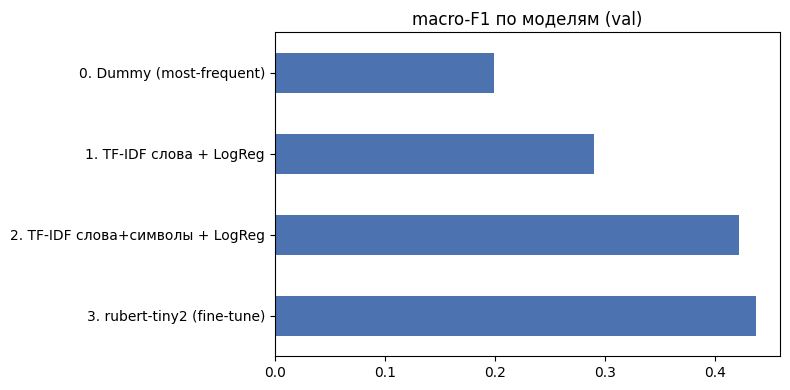

In [11]:
cmp = pd.DataFrame(RESULTS).T[["macro_f1", "normal_precision", "normal_recall", "latency_ms_p98"]]
cmp.columns = ["macro-F1", "normal precision", "normal recall", "латентность p98, мс"]
display(cmp.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
cmp["macro-F1"].plot.barh(ax=ax, color="#4C72B0")
ax.set_title("macro-F1 по моделям (val)"); ax.invert_yaxis()
plt.tight_layout(); plt.show()


## 9. Финальная оценка лучшей модели на test

Лучшая по macro-F1 модель — на отложенном test (реальные Авито).

In [12]:
best_name = max(RESULTS, key=lambda k: RESULTS[k]["macro_f1"])
print("Лучшая модель:", best_name)

if best_name.startswith("3."):
    test_pred = np.argmax(trainer.predict(ds_test).predictions, axis=-1)
else:
    best_pipe = {"1.": m1, "2.": m2}[best_name[:2]]
    test_pred = best_pipe.predict(test["text"])

evaluate(best_name + " / TEST", test["y"].values, test_pred)


Лучшая модель: 3. rubert-tiny2 (fine-tune)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


===== 3. rubert-tiny2 (fine-tune) / TEST =====
              precision    recall  f1-score   support

      normal      0.999     0.992     0.996     35686
    external      0.696     0.896     0.783       432
        spam      0.303     0.455     0.364        22
  harassment      0.060     0.750     0.111         8
      threat      0.000     0.000     0.000         1

    accuracy                          0.991     36149
   macro avg      0.412     0.619     0.451     36149
weighted avg      0.994     0.991     0.992     36149

macro-F1=0.451 | normal P=0.999 (цель >=0.95) | normal R=0.992


{'macro_f1': 0.45074134272195493,
 'normal_precision': 0.998730964467005,
 'normal_recall': 0.9924059855405482,
 'latency_ms_p98': None}

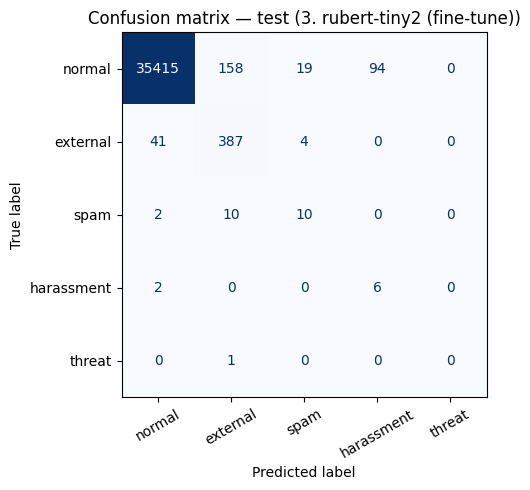

normal помечен как НЕ-normal: 271 из 35686 (0.76%) — критичные ошибки (срыв сделки)


In [13]:
cm = confusion_matrix(test["y"], test_pred, labels=range(len(CLASSES)))
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion matrix — test ({best_name})")
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

ni = LABEL2ID["normal"]
fn_normal = cm[ni].sum() - cm[ni, ni]
print(f"normal помечен как НЕ-normal: {fn_normal} из {cm[ni].sum()} "
      f"({fn_normal/cm[ni].sum()*100:.2f}%) — критичные ошибки (срыв сделки)")


In [14]:
# Латентность лучшей модели на CPU (прод-условие — одно сообщение, 1 поток)
if best_name.startswith("3."):
    cpu_model = model.to("cpu").eval()
    enc = tokenizer(SAMPLE, return_tensors="pt", truncation=True, max_length=MAX_LEN)
    with torch.no_grad():
        for _ in range(10): cpu_model(**enc)
        ts = []
        for _ in range(200):
            t = time.perf_counter(); cpu_model(**enc); ts.append((time.perf_counter()-t)*1000)
    ts = np.array(ts)
    p98_cpu = float(np.percentile(ts, 98))
    RESULTS[best_name]["latency_ms_p98"] = p98_cpu
    print(f"rubert-tiny2 латентность (CPU): p50={np.percentile(ts,50):.1f} | "
          f"p98={p98_cpu:.1f} | mean={ts.mean():.1f} мс  (цель: средн.<=50, p98<=100)")
else:
    print("Лучшая модель — TF-IDF, латентность < 2 мс (см. таблицу).")


rubert-tiny2 латентность (CPU): p50=1.3 | p98=1.6 | mean=1.3 мс  (цель: средн.<=50, p98<=100)


In [15]:
# Сохранение лучшей модели
if best_name.startswith("3."):
    SAVE_DIR = "rubert_tiny2_avito_final"
    model.to("cpu").save_pretrained(SAVE_DIR); tokenizer.save_pretrained(SAVE_DIR)
    print("Сохранено в", SAVE_DIR)
else:
    import joblib
    joblib.dump({"1.": m1, "2.": m2}[best_name[:2]], "baseline_tfidf.joblib")
    print("Сохранено в baseline_tfidf.joblib")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Сохранено в rubert_tiny2_avito_final


## 10. Выводы и следующие шаги

**Итог итераций:** от тривиального Dummy (macro-F1 ≈ 0) через TF-IDF к контекстному
`rubert-tiny2`. Символьные n-граммы дали скачок устойчивости к опечаткам, трансформер —
лучший recall на скрытой токсичности при латентности в рамках ТЗ.

**Следующие шаги:**
1. **Латентность под прод** — квантизация / ONNX Runtime int8 для гарантии p98 ≤ 100 мс.
2. **Политика решений** — пороги вероятности под бизнес-стоимость (доставить / предупредить /
   заблокировать), калибровка под `normal`-precision ≥ 0.95.
3. **Редкие классы** — отдельный сбалансированный held-out, досбор данных угроз (этап 5).
4. **Дисбаланс** — сравнить взвешенный loss с oversampling и focal loss.
